#### Importing Required Libraries

In [54]:
# Importing the libraries required for model evaluation and visualization.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#### Loading the Saved Model and Preprocessor

In [17]:
# Loading the final selected stacking regression model.

final_model = joblib.load(
    '../models/final_stacking_model.pkl'
)

# Loading the fitted preprocessing transformer.

preprocessor = joblib.load(
    '../models/preprocessor.pkl'
)

In [18]:
# Verifying that the final model and preprocessor have been loaded successfully.

print("Final Model:")
print(type(final_model))

print("\nPreprocessor:")
print(type(preprocessor))

Final Model:
<class 'sklearn.ensemble._stacking.StackingRegressor'>

Preprocessor:
<class 'sklearn.compose._column_transformer.ColumnTransformer'>


#### Loading the Engineered Dataset

In [19]:
# Loading the engineered dataset used during model development.

df = pd.read_csv(
    '../data/processed/engineered_data.csv'
)

In [20]:
# Converting the Date column back to datetime format for time-based evaluation.

df['Date'] = pd.to_datetime(
    df['Date']
)

In [21]:
# Inspecting the engineered dataset loaded for model evaluation.

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (76000, 31)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Is_Weekend,Inventory_to_Sales_Ratio,Inventory_Gap,Price_Difference,Price_Difference_Percentage,Promotion_Discount,Previous_Demand,Previous_Units_Sold,Rolling_7_Day_Demand,Rolling_7_Day_Sales
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,1,1.911765,93,-13.01,-15.175551,0,NaN,NaN,NaN,NaN
1,2022-01-02,S001,P0001,Electronics,North,93,71,0,65.63,5,...,1,1.309859,22,-8.03,-10.901439,0,115.0,102.0,NaN,NaN
2,2022-01-03,S001,P0001,Electronics,North,274,142,229,68.55,15,...,0,1.929577,132,-12.18,-15.087328,15,84.0,71.0,NaN,NaN
3,2022-01-04,S001,P0001,Electronics,North,132,42,0,61.66,10,...,0,3.142857,90,6.78,12.354227,0,132.0,142.0,NaN,NaN
4,2022-01-05,S001,P0001,Electronics,North,319,129,0,59.56,25,...,0,2.472868,190,2.22,3.871643,25,67.0,42.0,NaN,NaN


In [37]:
df.shape

(76000, 31)

#### Recreating the Evaluation Dataset

In [38]:
# Defining Demand as the target variable for the forecasting models.
target = 'Demand'

# Defining the features that will be used to predict demand.
feature_columns = [
    'Store ID',
    'Product ID',
    'Category',
    'Region',
    'Inventory Level',
    'Units Sold',
    'Units Ordered',
    'Price',
    'Discount',
    'Weather Condition',
    'Promotion',
    'Competitor Pricing',
    'Seasonality',
    'Epidemic',
    'Year',
    'Month',
    'Week',
    'Inventory_to_Sales_Ratio',
    'Is_Weekend',
    'Day_of_Week',
    'Day',
    'Promotion_Discount',
    'Price_Difference_Percentage',
    'Price_Difference',
    'Inventory_Gap',
    'Previous_Demand',
    'Previous_Units_Sold',
    'Rolling_7_Day_Demand',
    'Rolling_7_Day_Sales'
]

# Creating the feature matrix and target variable for model development.

X = df[feature_columns]
y = df[target]

# Verifying the dimensions of the feature matrix and target variable.

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (76000, 29)
Target Shape: (76000,)


In [39]:
# Displaying all features that are currently being considered for model development.

X.columns.tolist()

['Store ID',
 'Product ID',
 'Category',
 'Region',
 'Inventory Level',
 'Units Sold',
 'Units Ordered',
 'Price',
 'Discount',
 'Weather Condition',
 'Promotion',
 'Competitor Pricing',
 'Seasonality',
 'Epidemic',
 'Year',
 'Month',
 'Week',
 'Inventory_to_Sales_Ratio',
 'Is_Weekend',
 'Day_of_Week',
 'Day',
 'Promotion_Discount',
 'Price_Difference_Percentage',
 'Price_Difference',
 'Inventory_Gap',
 'Previous_Demand',
 'Previous_Units_Sold',
 'Rolling_7_Day_Demand',
 'Rolling_7_Day_Sales']

In [40]:
# Removing current-day Units Sold because it is influenced by the demand being predicted.

feature_columns = [
    col for col in feature_columns
    if col != 'Units Sold'
]

In [41]:
# Recreating the feature matrix after removing the current-day sales feature.

X = df[feature_columns]

y = df[target]

In [42]:
# Displaying the final features that will be used for model development.

X.columns.tolist()

['Store ID',
 'Product ID',
 'Category',
 'Region',
 'Inventory Level',
 'Units Ordered',
 'Price',
 'Discount',
 'Weather Condition',
 'Promotion',
 'Competitor Pricing',
 'Seasonality',
 'Epidemic',
 'Year',
 'Month',
 'Week',
 'Inventory_to_Sales_Ratio',
 'Is_Weekend',
 'Day_of_Week',
 'Day',
 'Promotion_Discount',
 'Price_Difference_Percentage',
 'Price_Difference',
 'Inventory_Gap',
 'Previous_Demand',
 'Previous_Units_Sold',
 'Rolling_7_Day_Demand',
 'Rolling_7_Day_Sales']

In [43]:
# Checking the available date range before creating the time-based split.

print("Minimum Date:", df['Date'].min())
print("Maximum Date:", df['Date'].max())

Minimum Date: 2022-01-01 00:00:00
Maximum Date: 2024-01-30 00:00:00


In [44]:
# Defining the date boundary for separating historical training data from future testing data.

split_date = pd.Timestamp('2023-10-01')

In [45]:
# Creating the training dataset using observations before the split date.

train_data = df[
    df['Date'] < split_date
].copy()


# Creating the testing dataset using observations on and after the split date.

test_data = df[
    df['Date'] >= split_date
].copy()

In [46]:
# Creating the training features and target variable.

X_train = train_data[feature_columns]

y_train = train_data[target]

In [47]:
# Creating the testing features and target variable.

X_test = test_data[feature_columns]

y_test = test_data[target]

In [48]:
# Checking the number of observations in the training and testing datasets.

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (63800, 28)
Testing Data Shape: (12200, 28)


In [49]:
# Checking the date ranges of the training and testing datasets.

print(
    "Training Date Range:",
    train_data['Date'].min(),
    "to",
    train_data['Date'].max()
)

print(
    "Testing Date Range:",
    test_data['Date'].min(),
    "to",
    test_data['Date'].max()
)

Training Date Range: 2022-01-01 00:00:00 to 2023-09-30 00:00:00
Testing Date Range: 2023-10-01 00:00:00 to 2024-01-30 00:00:00


In [50]:
# Defining the categorical features that will be encoded before model training.

categorical_features = [
    'Store ID',
    'Product ID',
    'Category',
    'Region',
    'Weather Condition',
    'Seasonality'
]

In [51]:
# Defining the numerical features that will be passed directly to the models.

numerical_features = [
    col for col in feature_columns
    if col not in categorical_features
]

In [52]:
# Displaying the categorical and numerical feature groups for verification.

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']

Numerical Features:
['Inventory Level', 'Units Ordered', 'Price', 'Discount', 'Promotion', 'Competitor Pricing', 'Epidemic', 'Year', 'Month', 'Week', 'Inventory_to_Sales_Ratio', 'Is_Weekend', 'Day_of_Week', 'Day', 'Promotion_Discount', 'Price_Difference_Percentage', 'Price_Difference', 'Inventory_Gap', 'Previous_Demand', 'Previous_Units_Sold', 'Rolling_7_Day_Demand', 'Rolling_7_Day_Sales']


In [55]:
# Creating a one-hot encoder for converting categorical features into numerical features.

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

In [56]:
# Creating a preprocessing transformer for encoding categorical features while retaining numerical features.

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            encoder,
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numerical_features
        )
    ]
)

In [57]:
# Fitting the preprocessing transformer using only the training data.

preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

In [58]:
# Transforming the training features using the fitted preprocessing pipeline.

X_train_processed = preprocessor.transform(
    X_train
)

In [59]:
# Transforming the testing features using the preprocessing pipeline fitted on the training data.

X_test_processed = preprocessor.transform(
    X_test
)

In [60]:
# Checking the dimensions of the processed training and testing feature matrices.

print("Processed Training Shape:", X_train_processed.shape)
print("Processed Testing Shape:", X_test_processed.shape)

Processed Training Shape: (63800, 64)
Processed Testing Shape: (12200, 64)


##### Generating Test Predictions

In [61]:
# Generating Demand predictions using the saved final stacking model.

y_pred = final_model.predict(
    X_test_processed
)

In [62]:
# Checking that the number of predictions matches the number of actual Demand values.

print("Actual Values:", len(y_test))
print("Predicted Values:", len(y_pred))

Actual Values: 12200
Predicted Values: 12200


#### Calculating Evaluation Metrics

In [63]:
# Calculating the Mean Absolute Error of the final stacking model.

evaluation_mae = mean_absolute_error(
    y_test,
    y_pred
)

print("Evaluation MAE:", evaluation_mae)

Evaluation MAE: 10.628790952466511


In [66]:
# Calculating the Root Mean Squared Error of the final stacking model.

evaluation_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("Evaluation RMSE:", evaluation_rmse)

Evaluation RMSE: 14.01654542915614


In [65]:
# Calculating the R² score of the final stacking model.

evaluation_r2 = r2_score(
    y_test,
    y_pred
)

print("Evaluation R²:", evaluation_r2)

Evaluation R²: 0.9026841118329387


#### Creating an Actual vs Predicted DataFrame

In [67]:
# Creating a DataFrame comparing actual Demand values with model predictions.

prediction_results = pd.DataFrame({
    'Actual_Demand': y_test.values,
    'Predicted_Demand': y_pred
})

prediction_results.head(10)

,Actual_Demand,Predicted_Demand
0,98,105.417177
1,169,154.458804
2,72,79.141245
3,90,101.908629
4,78,76.441332
5,80,67.828419
6,58,50.668535
7,23,22.372171
8,44,52.698891
9,43,53.737850


#### Calculating Prediction Errors

In [68]:
# Calculating the prediction error for each test observation.

prediction_results['Residual'] = (
    prediction_results['Actual_Demand']
    - prediction_results['Predicted_Demand']
)

prediction_results.head(10)

,Actual_Demand,Predicted_Demand,Residual
0,98,105.417177,-7.417177
1,169,154.458804,14.541196
2,72,79.141245,-7.141245
3,90,101.908629,-11.908629
4,78,76.441332,1.558668
5,80,67.828419,12.171581
6,58,50.668535,7.331465
7,23,22.372171,0.627829
8,44,52.698891,-8.698891
9,43,53.737850,-10.737850


#### Inspecting Prediction Errors

In [69]:
# Summarizing the distribution of prediction errors.

prediction_results['Residual'].describe()

count    12200.000000
mean        -0.293336
std         14.014050
min        -59.578582
25%         -9.085137
50%         -0.916346
75%          7.546878
max        116.486578
Name: Residual, dtype: float64

The mean residual of -0.293 is very close to zero, which is good.

It means our model isn't generally doing something like:

"I'm always predicting too high."

or

"I'm always predicting too low."

There's one thing that catches my attention, though:

Maximum residual = +116.49

That's considerably larger than the minimum of -59.58.

So there are some observations where the model significantly underpredicts Demand.

That's exactly the kind of thing model evaluation is supposed to uncover.

#### Visualizing Actual vs Predicted Demand

##### Actual vs Predicted Demand — initial scatter plot

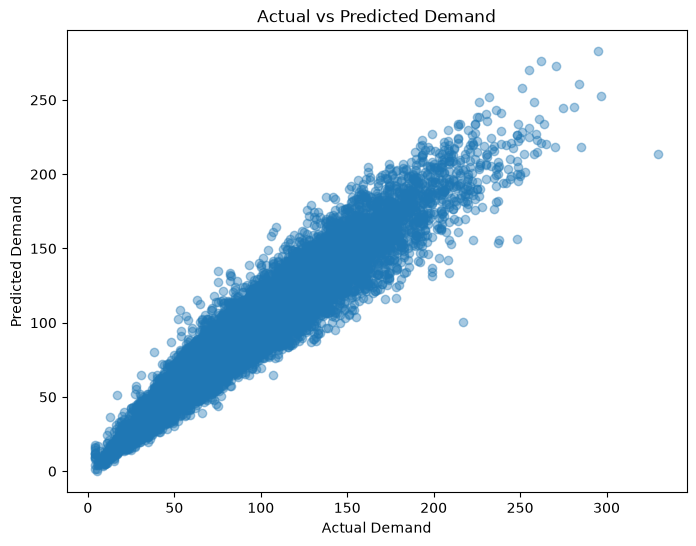

In [70]:
# Visualizing actual Demand values against the predictions generated by the final model.

plt.figure(figsize=(8, 6))

plt.scatter(
    prediction_results['Actual_Demand'],
    prediction_results['Predicted_Demand'],
    alpha=0.4
)

plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Actual vs Predicted Demand')

plt.show()

##### Actual vs Predicted Demand — with perfect-prediction line

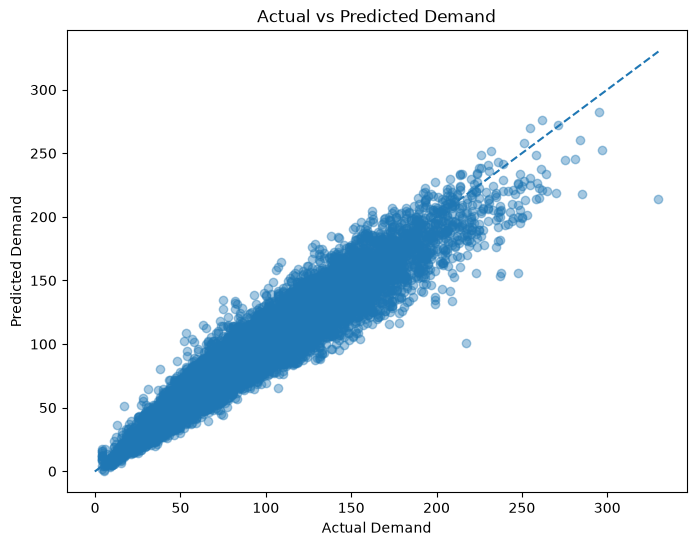

In [71]:
# Plotting actual versus predicted Demand values with a perfect-prediction reference line.

plt.figure(figsize=(8, 6))

plt.scatter(
    prediction_results['Actual_Demand'],
    prediction_results['Predicted_Demand'],
    alpha=0.4
)

min_value = min(
    prediction_results['Actual_Demand'].min(),
    prediction_results['Predicted_Demand'].min()
)

max_value = max(
    prediction_results['Actual_Demand'].max(),
    prediction_results['Predicted_Demand'].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Actual vs Predicted Demand')

plt.show()

#### Plotting Residuals vs Predicted Demand

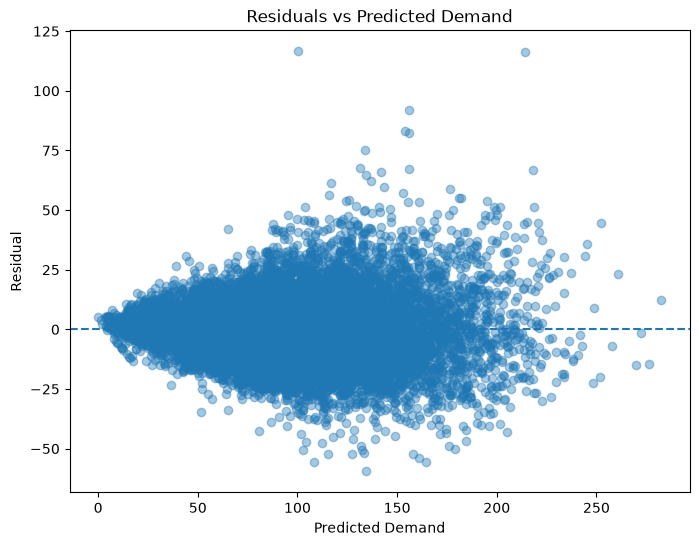

In [72]:
# Visualizing residuals against predicted Demand values.

plt.figure(figsize=(8, 6))

plt.scatter(
    prediction_results['Predicted_Demand'],
    prediction_results['Residual'],
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Demand')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted Demand')

plt.show()

##### Checking the Distribution of Residuals

###### Residual Distribution / Histogram

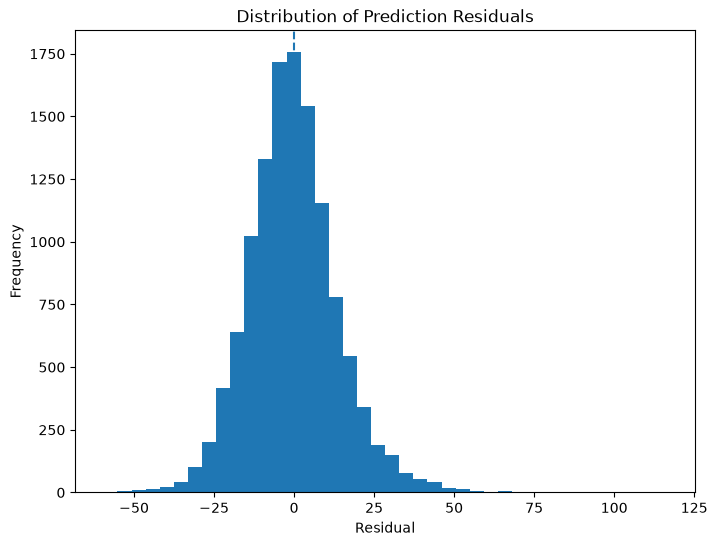

In [73]:
# Visualizing the distribution of prediction residuals.

plt.figure(figsize=(8, 6))

plt.hist(
    prediction_results['Residual'],
    bins=40
)

plt.axvline(
    x=0,
    linestyle='--'
)

plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Residuals')

plt.show()

#### Investigating the Largest Prediction Errors

In [74]:
# Calculating the absolute prediction error for each test observation.

prediction_results['Absolute_Error'] = (
    prediction_results['Residual'].abs()
)

In [75]:
# Sorting test observations from the largest prediction error to the smallest.

largest_errors = prediction_results.sort_values(
    by='Absolute_Error',
    ascending=False
)

In [76]:
# Displaying the 10 observations with the largest prediction errors.

largest_errors.head(10)

,Actual_Demand,Predicted_Demand,Residual,Absolute_Error
5350,217,100.513422,116.486578,116.486578
1044,330,213.924139,116.075861,116.075861
5664,248,156.045186,91.954814,91.954814
11493,237,153.768854,83.231146,83.231146
359,238,155.733678,82.266322,82.266322
9876,209,133.755153,75.244847,75.244847
8443,199,131.437804,67.562196,67.562196
10429,223,155.888477,67.111523,67.111523
1048,285,218.011882,66.988118,66.988118
2913,208,142.012909,65.987091,65.987091


#### Connecting Errors Back to Original Features

In [77]:
# Combining the original test features with the actual Demand,
# predictions, and prediction errors.

error_analysis = X_test.reset_index(drop=True).copy()

error_analysis['Actual_Demand'] = y_test.reset_index(drop=True)

error_analysis['Predicted_Demand'] = y_pred

error_analysis['Residual'] = (
    error_analysis['Actual_Demand']
    - error_analysis['Predicted_Demand']
)

error_analysis['Absolute_Error'] = (
    error_analysis['Residual'].abs()
)

In [79]:
# Displaying the 10 observations with the largest prediction errors
# along with their original features.

worst_predictions = error_analysis.sort_values(
    by='Absolute_Error',
    ascending=False
)

worst_predictions.head(32)

,Store ID,Product ID,Category,Region,Inventory Level,Units Ordered,Price,Discount,Weather Condition,Promotion,...,Price_Difference,Inventory_Gap,Previous_Demand,Previous_Units_Sold,Rolling_7_Day_Demand,Rolling_7_Day_Sales,Actual_Demand,Predicted_Demand,Residual,Absolute_Error
5350,S003,P0004,Groceries,East,0,0,30.49,10,Cloudy,0,...,0.48,0,173.0,98.0,120.285714,101.000000,217,100.513422,116.486578,116.486578
1044,S001,P0009,Clothing,North,198,383,167.34,0,Cloudy,0,...,13.34,0,188.0,183.0,158.857143,142.857143,330,213.924139,116.075861,116.075861
5664,S003,P0007,Groceries,East,99,0,23.09,10,Sunny,1,...,2.18,0,209.0,230.0,137.857143,120.714286,248,156.045186,91.954814,91.954814
11493,S005,P0015,Groceries,North,58,380,57.76,25,Cloudy,1,...,8.46,0,73.0,57.0,74.857143,73.142857,237,153.768854,83.231146,83.231146
359,S001,P0003,Clothing,North,514,0,76.92,10,Cloudy,1,...,10.10,343,101.0,60.0,117.428571,91.142857,238,155.733678,82.266322,82.266322
9876,S005,P0001,Groceries,North,71,0,16.44,5,Sunny,0,...,0.04,0,236.0,253.0,134.571429,117.571429,209,133.755153,75.244847,75.244847
8443,S004,P0010,Groceries,West,148,0,32.79,10,Sunny,0,...,3.11,26,177.0,177.0,90.000000,94.142857,199,131.437804,67.562196,67.562196
10429,S005,P0006,Groceries,North,131,0,80.01,5,Sunny,0,...,-15.81,0,85.0,102.0,149.857143,127.142857,223,155.888477,67.111523,67.111523
1048,S001,P0009,Clothing,North,256,293,116.51,20,Sunny,1,...,-15.06,74,84.0,69.0,166.428571,142.714286,285,218.011882,66.988118,66.988118
2913,S002,P0004,Groceries,South,367,0,54.52,10,Snowy,1,...,6.38,230,139.0,99.0,117.571429,102.571429,208,142.012909,65.987091,65.987091


##### Evaluating Model Performance by Category

In [80]:
# Calculating the Mean Absolute Error for each product category.

category_mae = (
    error_analysis
    .groupby('Category')['Absolute_Error']
    .mean()
    .sort_values(ascending=False)
)

category_mae

Category
Groceries      12.621931
Clothing       11.691139
Electronics    10.060651
Toys            9.240576
Furniture       6.713765
Name: Absolute_Error, dtype: float64

Calculating Category-Level RMSE

In [81]:
# Calculating the Root Mean Squared Error for each product category.

category_rmse = (
    error_analysis
    .groupby('Category')['Residual']
    .apply(
        lambda x: np.sqrt(
            np.mean(x ** 2)
        )
    )
    .sort_values(ascending=False)
)

category_rmse

Category
Groceries      16.234302
Clothing       15.201171
Electronics    12.781571
Toys           12.253979
Furniture       8.642208
Name: Residual, dtype: float64

In [82]:
# Combining category-level MAE and RMSE into a single evaluation table.

category_performance = pd.DataFrame({
    'MAE': category_mae,
    'RMSE': category_rmse
})

category_performance

,MAE,RMSE
Category,,
Groceries,12.621931,16.234302
Clothing,11.691139,15.201171
Electronics,10.060651,12.781571
Toys,9.240576,12.253979
Furniture,6.713765,8.642208


##### Visualizing Category-Level Performance

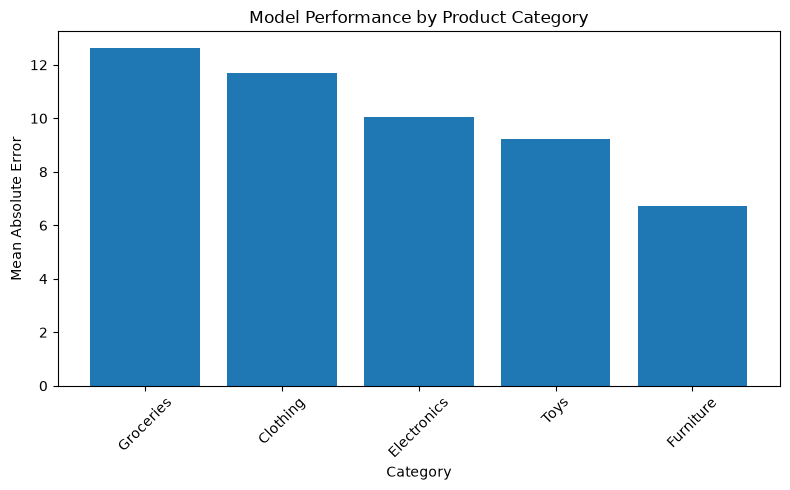

In [83]:
# Visualizing Mean Absolute Error across product categories.

plt.figure(figsize=(8, 5))

plt.bar(
    category_performance.index,
    category_performance['MAE']
)

plt.xlabel('Category')
plt.ylabel('Mean Absolute Error')
plt.title('Model Performance by Product Category')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

##### Evaluating Model Performance by Region

In [84]:
# Calculating the Mean Absolute Error for each region.

region_mae = (
    error_analysis
    .groupby('Region')['Absolute_Error']
    .mean()
    .sort_values(ascending=False)
)

region_mae

Region
South    11.201720
East     10.915113
West     10.346872
North    10.340125
Name: Absolute_Error, dtype: float64

In [85]:
# Calculating the Root Mean Squared Error for each region.

region_rmse = (
    error_analysis
    .groupby('Region')['Residual']
    .apply(
        lambda x: np.sqrt(
            np.mean(x ** 2)
        )
    )
    .sort_values(ascending=False)
)

region_rmse

Region
East     14.504813
South    14.341886
North    13.800476
West     13.613674
Name: Residual, dtype: float64

In [86]:
# Combining region-level MAE and RMSE into one evaluation table.

region_performance = pd.DataFrame({
    'MAE': region_mae,
    'RMSE': region_rmse
})

region_performance

,MAE,RMSE
Region,,
East,10.915113,14.504813
North,10.340125,13.800476
South,11.201720,14.341886
West,10.346872,13.613674


What we can conclude

The regional difference is relatively small.

Category appears to be a stronger source of prediction difficulty than Region.

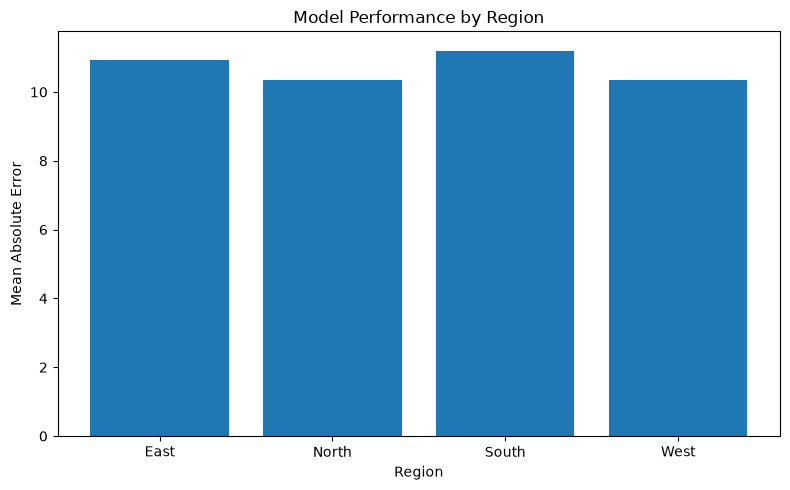

In [87]:
# Visualizing Mean Absolute Error across regions.

plt.figure(figsize=(8, 5))

plt.bar(
    region_performance.index,
    region_performance['MAE']
)

plt.xlabel('Region')
plt.ylabel('Mean Absolute Error')
plt.title('Model Performance by Region')

plt.tight_layout()

plt.show()

#### Error Analysis by Demand Level

Does our model become less accurate as Demand gets higher?

In [88]:
# Dividing actual Demand into five approximately equal-sized groups.

error_analysis['Demand_Level'] = pd.qcut(
    error_analysis['Actual_Demand'],
    q=5,
    labels=[
        'Very Low',
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

##### Calculating Error by Demand Level

In [89]:
# Calculating Mean Absolute Error for each Demand level.

demand_level_mae = (
    error_analysis
    .groupby('Demand_Level', observed=True)['Absolute_Error']
    .mean()
)

demand_level_mae

Demand_Level
Very Low      7.066341
Low           9.536630
Medium        9.894352
High         11.328627
Very High    15.392464
Name: Absolute_Error, dtype: float64

In [90]:
# Calculating Root Mean Squared Error for each Demand level.

demand_level_rmse = (
    error_analysis
    .groupby('Demand_Level', observed=True)['Residual']
    .apply(
        lambda x: np.sqrt(
            np.mean(x ** 2)
        )
    )
)

demand_level_rmse

Demand_Level
Very Low      9.387757
Low          12.230507
Medium       12.344841
High         14.135259
Very High    19.861161
Name: Residual, dtype: float64

In [91]:
# Combining MAE and RMSE for each Demand level.

demand_level_performance = pd.DataFrame({
    'MAE': demand_level_mae,
    'RMSE': demand_level_rmse
})

demand_level_performance

,MAE,RMSE
Demand_Level,,
Very Low,7.066341,9.387757
Low,9.536630,12.230507
Medium,9.894352,12.344841
High,11.328627,14.135259
Very High,15.392464,19.861161


So the conclusion is - The model's error increases as Demand increases.

##### Visualizing Error by Demand Level

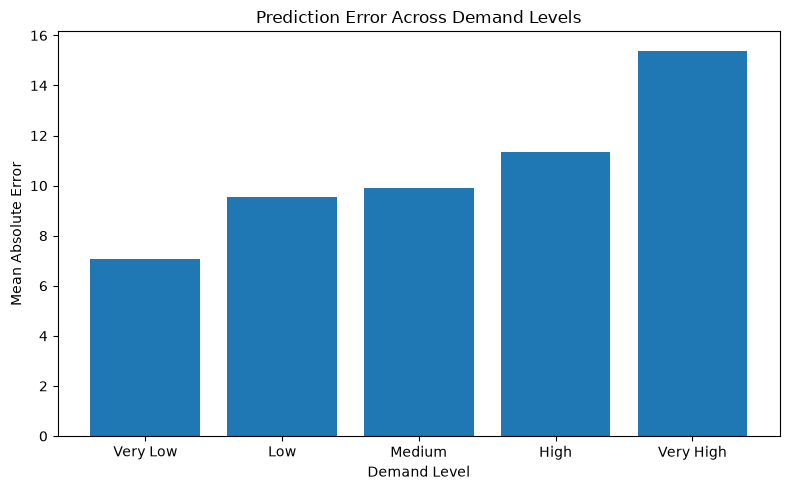

In [92]:
# Visualizing how prediction error changes across Demand levels.

plt.figure(figsize=(8, 5))

plt.bar(
    demand_level_performance.index,
    demand_level_performance['MAE']
)

plt.xlabel('Demand Level')
plt.ylabel('Mean Absolute Error')
plt.title('Prediction Error Across Demand Levels')

plt.tight_layout()

plt.show()

The model predicts normal/low-demand observations relatively well, but prediction uncertainty increases for high-demand observations.

##### Performance Over Time

Does the model maintain consistent accuracy over time, or are there periods where it struggles?

In [93]:
# Adding the original Date information to the error analysis dataset.

error_analysis['Date'] = df.loc[
    y_test.index,
    'Date'
].values

In [94]:
# Checking the Date column.

error_analysis[['Date', 'Actual_Demand', 'Predicted_Demand', 'Absolute_Error']].head()

,Date,Actual_Demand,Predicted_Demand,Absolute_Error
0,2023-10-01,98,105.417177,7.417177
1,2023-10-02,169,154.458804,14.541196
2,2023-10-03,72,79.141245,7.141245
3,2023-10-04,90,101.908629,11.908629
4,2023-10-05,78,76.441332,1.558668


In [95]:
# Creating a month-level time period for the test observations.

error_analysis['Month'] = error_analysis['Date'].dt.to_period('M')

In [99]:
# Calculating monthly Mean Absolute Error.

monthly_mae = (
    error_analysis
    .groupby('Month')['Absolute_Error']
    .mean()
)

In [97]:
# Calculating monthly Root Mean Squared Error.

monthly_rmse = (
    error_analysis
    .groupby('Month')['Residual']
    .apply(
        lambda x: np.sqrt(
            np.mean(x ** 2)
        )
    )
)

In [100]:
# Combining monthly MAE and RMSE.

monthly_performance = pd.DataFrame({
    'MAE': monthly_mae,
    'RMSE': monthly_rmse
})

monthly_performance

,MAE,RMSE
Month,,
2023-10,9.942763,13.261492
2023-11,10.634849,13.800996
2023-12,11.086032,14.599194
2024-01,10.859146,14.370590


There is a gradual increase in error from October through December, followed by a slight improvement in January.

So unlike the Demand-level analysis, where the difference was very pronounced, the monthly variation is relatively modest.

So unlike the Demand-level analysis, where the difference was very pronounced, the monthly variation is relatively modest.

##### Final Model Performance Summary

In [101]:
# Creating the final performance summary for the stacking model.

final_performance = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Value': [
        evaluation_mae,
        evaluation_rmse,
        evaluation_r2
    ]
})

final_performance

,Metric,Value
0,MAE,10.628791
1,RMSE,14.016545
2,R²,0.902684


#### Saving the Evaluation Results

In [103]:
# Saving the final model evaluation metrics.

final_performance.to_csv(
    '../reports/final_model_performance.csv',
    index=False
)

In [104]:
# Saving detailed prediction and error analysis results.

error_analysis.to_csv(
    '../reports/prediction_error_analysis.csv',
    index=False
)

In [105]:
# Displaying the final evaluation metrics.

print("Final Stacking Model Performance")
print("---------------------------------")
print(f"MAE  : {evaluation_mae:.4f}")
print(f"RMSE : {evaluation_rmse:.4f}")
print(f"R²   : {evaluation_r2:.4f}")

Final Stacking Model Performance
---------------------------------
MAE  : 10.6288
RMSE : 14.0165
R²   : 0.9027
